In [1]:
from preprocessing import Preprocessor
from utils import load_train_data

In [2]:
preprocessor = Preprocessor()
train = load_train_data()

/home/gshjis/Python_projects/apartment_rent_data/paсkages/utils/utils/data_loader.py:16: DtypeWarning: Columns (0: address) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv(train_path, encoding="windows-1252", sep=";")


In [3]:
train_processed = preprocessor.pipeline(
    df=train,
    mode="train",
    drop_columns_args={"columns": ["id", "category", "currency", "fee", "pets_allowed", "price_display", "price_type", "amenities"]},
    merge_columns_args={
        "col1": "cityname", 
        "col2": "state", 
        "new_col": "city_state",
        "drop_original": False
    },
    rare_categories_args={"columns": ["source"], "threshold": 0.05},
    anomaly_args={
        "city_col": "cityname", 
        "state_col": "state",
        "min_points_city": 30,
        "median_deviation_threshold": 0.3,
        "majority_ratio": 0.3
    },
    lda_type="weighted_correlation",
    lda_args={"text_column": "body", "n_topics": 20}
)

print(f"Аномальных городов: {len(preprocessor.anomaly_cities)}")
print(train_processed['anomaly_type'].value_counts())

ℹ️ preprocessor.py: 2026-03-23 12:26:36 INFO [preprocessing.preprocessor] pipeline: start (mode=train, lda_type=weighted_correlation)


ℹ️ preprocessor.py: 2026-03-23 12:26:36 INFO [preprocessing.preprocessor] fit_rare_categories: start (column=source, threshold=0.05)
ℹ️ preprocessor.py: 2026-03-23 12:26:36 INFO [preprocessing.preprocessor] fit_rare_categories: source: 23 rare values replaced with 'other' (threshold=0.05)
ℹ️ logger_file.py: 2026-03-23 12:26:36 INFO [preprocessing.preprocessor] ✅ fit_rare_categories: completed
ℹ️ preprocessor.py: 2026-03-23 12:26:50 INFO [preprocessing.preprocessor] fit_anomaly_cities: found 440 anomaly candidates with types
ℹ️ preprocessor.py: 2026-03-23 12:26:50 INFO [preprocessing.preprocessor] fit_lda: start (n_topics=20, text_column=body, alpha=0.01, eta=0.01)
ℹ️ LDA.py: 2026-03-23 12:26:50 INFO [analysis.LDA] LdaTopicModel: preprocessing start (text_column=body, n_rows_estimate=unknown)
ℹ️ logger_file.py: 2026-03-23 12:28:34 INFO [analysis.LDA] ✅ LdaTopicModel: preprocessing completed
ℹ️ LDA.py: 2026-03-23 12:28:44 INFO [analysis.LDA] LdaTopicModel: fit start (n_topics=20, passes=

In [30]:
train_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   title                       99492 non-null  str    
 1   bathrooms                   99429 non-null  float64
 2   bedrooms                    99368 non-null  float64
 3   has_photo                   99492 non-null  str    
 4   price                       99491 non-null  float64
 5   square_feet                 99492 non-null  int64  
 6   address                     7943 non-null   str    
 7   cityname                    99190 non-null  str    
 8   state                       99190 non-null  str    
 9   latitude                    99467 non-null  float64
 10  longitude                   99467 non-null  float64
 11  source                      99492 non-null  str    
 12  time                        99492 non-null  int64  
 13  city_state                  99492 non-null

Обычные города: 52721 строк (53.0%)
Premium города: 27027 строк (27.2%)
Budget города: 19744 строк (19.8%)


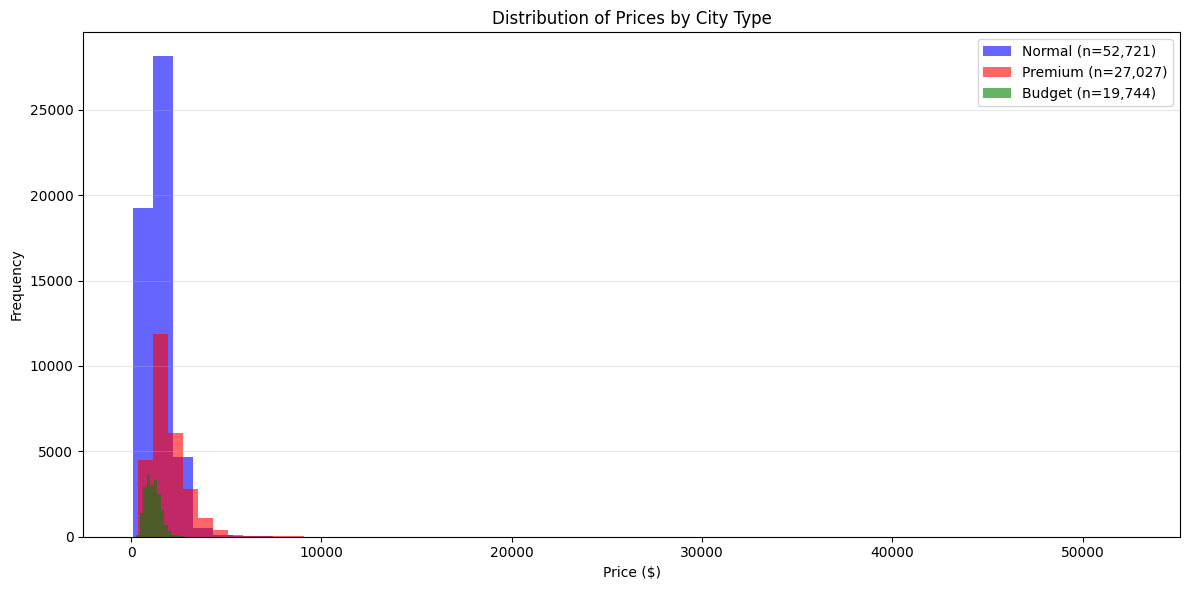


Колонки после удаления: ['bathrooms', 'bedrooms', 'has_photo', 'price', 'square_feet', 'latitude', 'longitude', 'source', 'time', 'city_state', 'is_anomaly', 'anomaly_type', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_weighted_correlation']

Обучение модели для normal городов
Train размер: 42074, Test размер: 10519
0:	learn: 685.9886725	total: 18.6ms	remaining: 27.8s
200:	learn: 315.1505063	total: 3.01s	remaining: 19.5s
400:	learn: 268.9549395	total: 5.63s	remaining: 15.4s
600:	learn: 244.5802263	total: 8.28s	remaining: 12.4s
800:	learn: 227.5550934	total: 10.9s	remaining: 9.51s
1000:	learn: 213.9908639	total: 13.5s	remaining: 6.74s
1200:	learn: 202.9937327	total: 16.2s	remaining: 4.03s
1400:	learn: 193.3657664	total: 18.9s	remaining: 1.33s
1499:	learn: 189.0966136	total: 20.2s	remaining: 0us

=

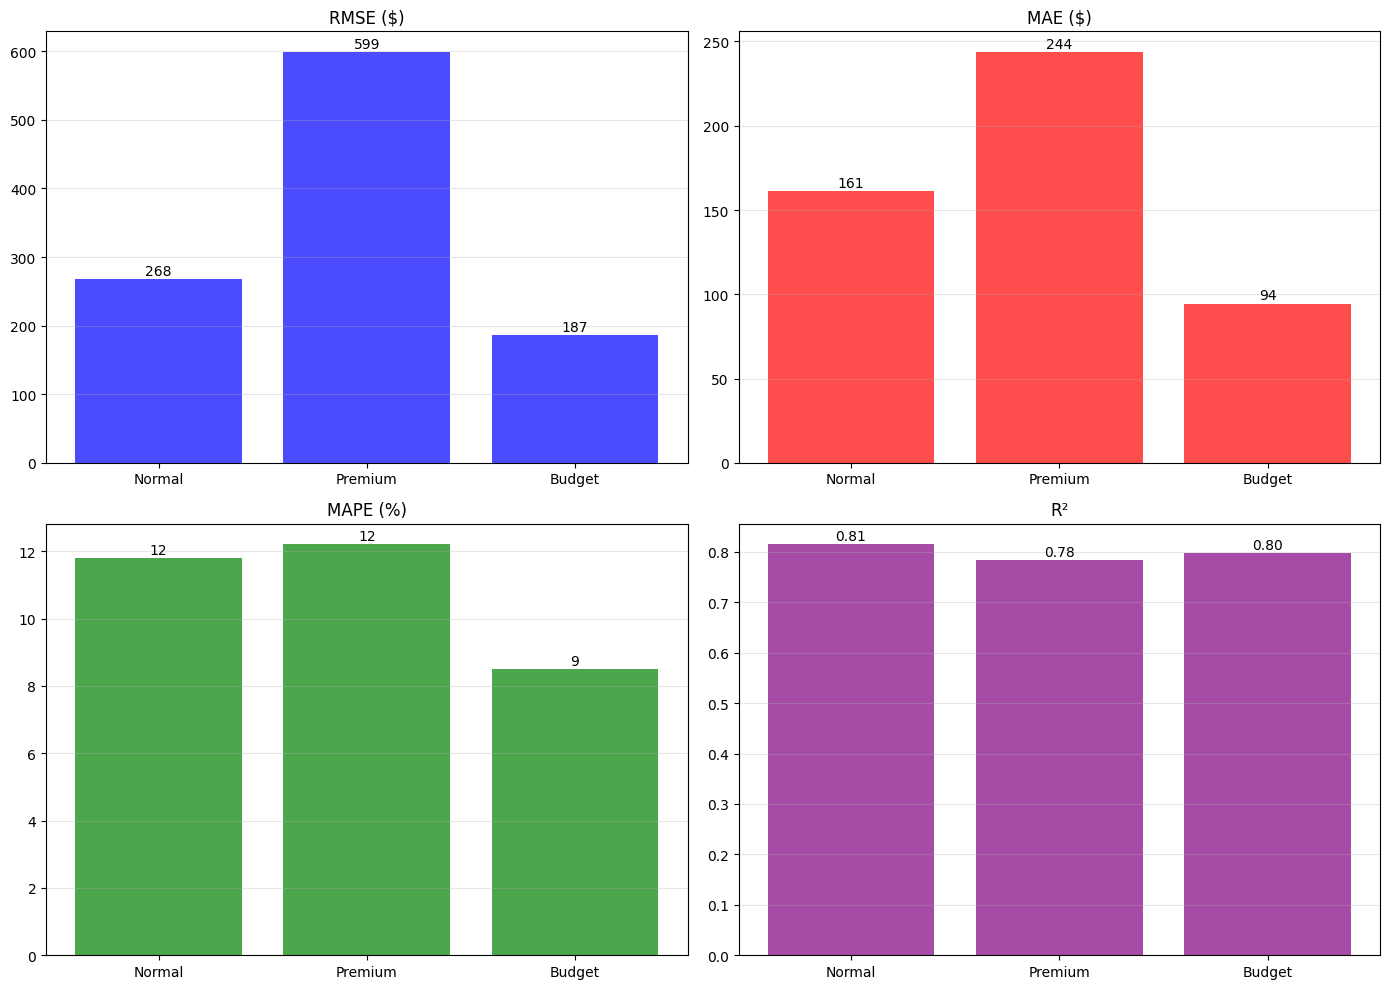

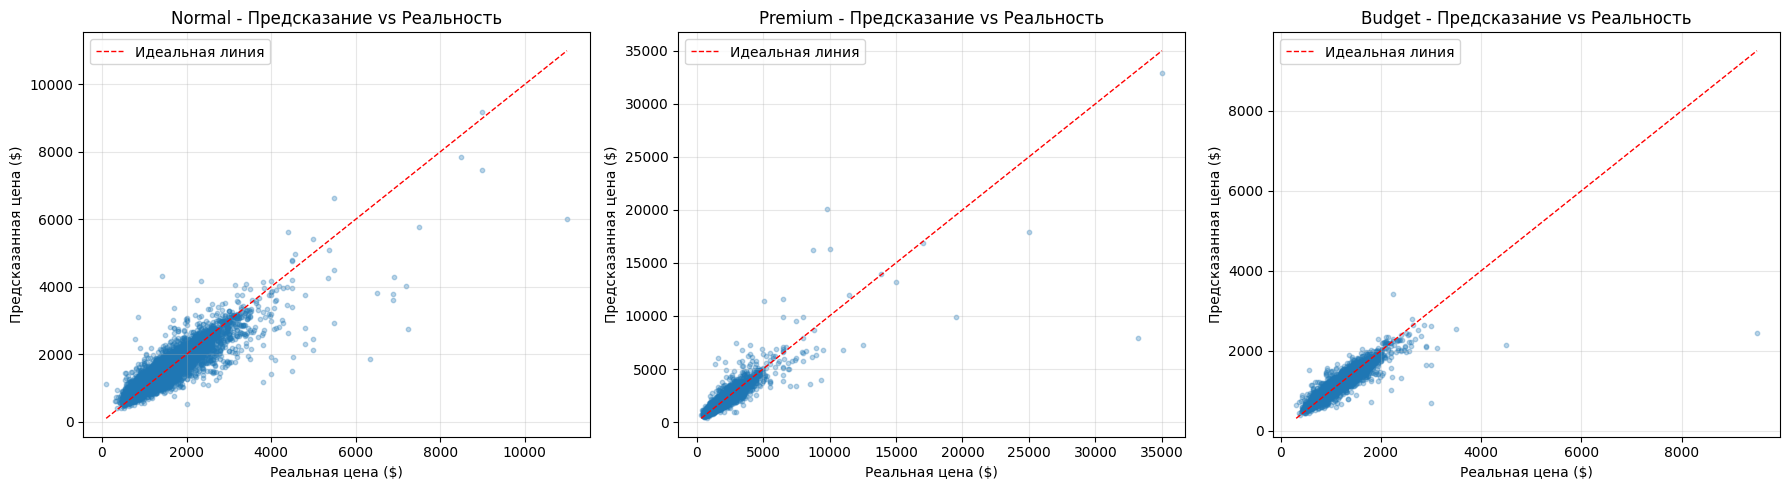


Топ-10 самых больших ошибок (normal):
 true_price  pred_price   abs_error  rel_error
    11000.0 6008.236138 4991.763862  45.379671
     7240.0 2758.014814 4481.985186  61.905873
     6330.0 1861.980569 4468.019431  70.584825
     6895.0 3601.396085 3293.603915  47.768005
     7200.0 4028.652365 3171.347635  44.046495
     6895.0 3772.043832 3122.956168  45.293055
     4500.0 1490.052936 3009.947064  66.887713
     1425.0 4325.350214 2900.350214 203.533348
     4995.0 2111.642854 2883.357146  57.724868
     6500.0 3820.875490 2679.124510  41.217300

Топ-10 самых больших ошибок (premium):
 true_price   pred_price    abs_error  rel_error
    33165.0  7962.646106 25202.353894  75.990815
     9800.0 20102.694212 10302.694212 105.129533
    19500.0  9904.802165  9595.197835  49.206143
     8750.0 16255.912321  7505.912321  85.781855
    25000.0 17876.208502  7123.791498  28.495166
     5100.0 11418.872846  6318.872846 123.899468
    10000.0 16309.152128  6309.152128  63.091521
     9395.0 

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# ============================================
# 1. Разделение на три датасета
# ============================================

normal_df = train_processed[train_processed['anomaly_type'] == 'normal'].copy()
premium_df = train_processed[train_processed['anomaly_type'] == 'premium'].copy()
budget_df = train_processed[train_processed['anomaly_type'] == 'budget'].copy()

print(f"Обычные города: {len(normal_df)} строк ({len(normal_df)/len(train_processed)*100:.1f}%)")
print(f"Premium города: {len(premium_df)} строк ({len(premium_df)/len(train_processed)*100:.1f}%)")
print(f"Budget города: {len(budget_df)} строк ({len(budget_df)/len(train_processed)*100:.1f}%)")

# ============================================
# 2. Гистограммы распределения цен
# ============================================

plt.figure(figsize=(12, 6))

plt.hist(normal_df['price'], bins=50, alpha=0.6, color='blue', label=f'Normal (n={len(normal_df):,})')
plt.hist(premium_df['price'], bins=50, alpha=0.6, color='red', label=f'Premium (n={len(premium_df):,})')
plt.hist(budget_df['price'], bins=50, alpha=0.6, color='green', label=f'Budget (n={len(budget_df):,})')

plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Prices by City Type')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 3. Удаление ненужных колонок
# ============================================

columns_to_drop = ['title', 'address', 'cityname', 'state']

normal_df = normal_df.drop(columns=columns_to_drop, errors='ignore').dropna()
premium_df = premium_df.drop(columns=columns_to_drop, errors='ignore').dropna()
budget_df = budget_df.drop(columns=columns_to_drop, errors='ignore').dropna()

print(f"\nКолонки после удаления: {normal_df.columns.tolist()}")

# ============================================
# 4. Определение признаков и целевой переменной
# ============================================

target = 'price'
cat_features = ['source', 'anomaly_type', 'city_state', 'has_photo']

# ============================================
# 5. Разделение на train/test и обучение моделей
# ============================================

models = {}
results = {}
errors = {}  # для хранения ошибок по каждому объекту

for name, df in [('normal', normal_df), ('premium', premium_df), ('budget', budget_df)]:
    print(f"\n{'='*50}")
    print(f"Обучение модели для {name} городов")
    print(f"{'='*50}")
    
    # Определяем признаки
    exclude_cols = [target, 'is_anomaly']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    existing_cat = [col for col in cat_features if col in df.columns]
    
    X = df[feature_cols]
    y = df[target]
    
    # Разделяем на train/test (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print(f"Train размер: {len(X_train)}, Test размер: {len(X_test)}")
    
    # Обучаем CatBoost
    model = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.1,
        depth=6,
        cat_features=existing_cat,
        verbose=200,
        random_seed=42
    )
    
    model.fit(X_train, y_train)
    models[name] = model
    
    # Предсказания
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Метрики на train
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mape = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Метрики на test
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Сохраняем ошибки для анализа
    errors[name] = {
        'y_true': y_test.values,
        'y_pred': y_test_pred,
        'absolute_error': np.abs(y_test - y_test_pred),
        'relative_error': np.abs((y_test - y_test_pred) / y_test) * 100
    }
    
    results[name] = {
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'train_mape': train_mape,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_mape': test_mape,
        'test_r2': test_r2,
        'n_train': len(X_train),
        'n_test': len(X_test)
    }
    
    print(f"\n=== Train метрики ===")
    print(f"  RMSE: ${train_rmse:,.0f}")
    print(f"  MAE: ${train_mae:,.0f}")
    print(f"  MAPE: {train_mape:.1f}%")
    print(f"  R²: {train_r2:.4f}")
    
    print(f"\n=== Test метрики ===")
    print(f"  RMSE: ${test_rmse:,.0f}")
    print(f"  MAE: ${test_mae:,.0f}")
    print(f"  MAPE: {test_mape:.1f}%")
    print(f"  R²: {test_r2:.4f}")

# ============================================
# 6. Сравнение результатов
# ============================================

print("\n" + "="*50)
print("Сравнение моделей (test метрики)")
print("="*50)

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['n_test', 'test_rmse', 'test_mae', 'test_mape', 'test_r2']]
comparison_df = comparison_df.round({'test_rmse': 0, 'test_mae': 0, 'test_mape': 1, 'test_r2': 4})
print(comparison_df)

# ============================================
# 7. Визуализация сравнения метрик
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['test_rmse', 'test_mae', 'test_mape', 'test_r2']
titles = ['RMSE ($)', 'MAE ($)', 'MAPE (%)', 'R²']
colors = ['blue', 'red', 'green', 'purple']

for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[i // 2, i % 2]
    values = [results[model][metric] for model in ['normal', 'premium', 'budget']]
    bars = ax.bar(['Normal', 'Premium', 'Budget'], values, color=color, alpha=0.7)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * max(values),
                f'{v:.2f}' if metric == 'test_r2' else f'{v:,.0f}',
                ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================
# 8. Анализ ошибок
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, ax) in enumerate(zip(['normal', 'premium', 'budget'], axes)):
    err = errors[name]
    
    # Scatter plot: предсказание vs реальное
    ax.scatter(err['y_true'], err['y_pred'], alpha=0.3, s=10)
    ax.plot([err['y_true'].min(), err['y_true'].max()], 
            [err['y_true'].min(), err['y_true'].max()], 
            'r--', linewidth=1, label='Идеальная линия')
    ax.set_xlabel('Реальная цена ($)')
    ax.set_ylabel('Предсказанная цена ($)')
    ax.set_title(f'{name.capitalize()} - Предсказание vs Реальность')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 9. Топ-10 ошибок для каждого типа
# ============================================

for name in ['normal', 'premium', 'budget']:
    err_df = pd.DataFrame({
        'true_price': errors[name]['y_true'],
        'pred_price': errors[name]['y_pred'],
        'abs_error': errors[name]['absolute_error'],
        'rel_error': errors[name]['relative_error']
    }).sort_values('abs_error', ascending=False)
    
    print(f"\n{'='*50}")
    print(f"Топ-10 самых больших ошибок ({name}):")
    print(f"{'='*50}")
    print(err_df.head(10).to_string(index=False))

print("\n✅ Анализ завершён!")

In [38]:
# ============================================
# Общие метрики по всем трём моделям
# ============================================

# Собираем все предсказания и реальные цены
all_y_true = []
all_y_pred = []

for name in ['normal', 'premium', 'budget']:
    all_y_true.extend(errors[name]['y_true'])
    all_y_pred.extend(errors[name]['y_pred'])

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

# Общие метрики
total_rmse = np.sqrt(mean_squared_error(all_y_true, all_y_pred))
total_mae = mean_absolute_error(all_y_true, all_y_pred)
total_mape = np.mean(np.abs((all_y_true - all_y_pred) / all_y_true)) * 100
total_r2 = r2_score(all_y_true, all_y_pred)

print("="*60)
print("ОБЩИЕ МЕТРИКИ (все три модели как одна)")
print("="*60)
print(f"Всего объектов в test: {len(all_y_true):,}")
print(f"RMSE: ${total_rmse:,.0f}")
print(f"MAE: ${total_mae:,.0f}")
print(f"MAPE: {total_mape:.1f}%")
print(f"R²: {total_r2:.4f}")

# Сравнение с отдельными моделями
print("\n" + "="*60)
print("СРАВНЕНИЕ С ОТДЕЛЬНЫМИ МОДЕЛЯМИ")
print("="*60)
print(f"{'Модель':<12} {'RMSE':>10} {'MAE':>10} {'MAPE':>10} {'R²':>10}")
print("-"*55)
print(f"{'Normal':<12} ${results['normal']['test_rmse']:>8,.0f} ${results['normal']['test_mae']:>8,.0f} {results['normal']['test_mape']:>9.1f}% {results['normal']['test_r2']:>9.4f}")
print(f"{'Premium':<12} ${results['premium']['test_rmse']:>8,.0f} ${results['premium']['test_mae']:>8,.0f} {results['premium']['test_mape']:>9.1f}% {results['premium']['test_r2']:>9.4f}")
print(f"{'Budget':<12} ${results['budget']['test_rmse']:>8,.0f} ${results['budget']['test_mae']:>8,.0f} {results['budget']['test_mape']:>9.1f}% {results['budget']['test_r2']:>9.4f}")
print("-"*55)
print(f"{'ОБЩАЯ':<12} ${total_rmse:>8,.0f} ${total_mae:>8,.0f} {total_mape:>9.1f}% {total_r2:>9.4f}")

ОБЩИЕ МЕТРИКИ (все три модели как одна)
Всего объектов в test: 19,857
RMSE: $378
MAE: $170
MAPE: 11.2%
R²: 0.8168

СРАВНЕНИЕ С ОТДЕЛЬНЫМИ МОДЕЛЯМИ
Модель             RMSE        MAE       MAPE         R²
-------------------------------------------------------
Normal       $     268 $     161      11.8%    0.8148
Premium      $     599 $     244      12.2%    0.7831
Budget       $     187 $      94       8.5%    0.7973
-------------------------------------------------------
ОБЩАЯ        $     378 $     170      11.2%    0.8168


In [58]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================
# Подготовка baseline данных (с текстом)
# ============================================

# Берём только нужные колонки
baseline_data = train.drop(columns=['price_display', 'price_type', 'title', 'address', 'cityname', 'state', 'category', 'id', 'amenities', 'currency', 'pets_allowed']).dropna()

# Добавляем текстовую колонку body (она должна быть в train)
if 'body' in train.columns:
    baseline_data['body'] = train.loc[baseline_data.index, 'body']
    print(f"Добавлена колонка body")

print(f"Baseline данные: {len(baseline_data)} строк")
print(f"Колонки: {baseline_data.columns.tolist()}")

# ============================================
# Определение признаков и целевой
# ============================================

target = 'price'

# Категориальные признаки
cat_features = ['source', 'fee', 'has_photo']

# Текстовые признаки
text_features = ['body'] if 'body' in baseline_data.columns else []

# Признаки (все колонки кроме target)
feature_cols = [col for col in baseline_data.columns if col != target]
X = baseline_data[feature_cols]
y = baseline_data[target]

# ============================================
# Разделение на train/test
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain размер: {len(X_train)}")
print(f"Test размер: {len(X_test)}")

# ============================================
# Обучение CatBoost с текстовыми признаками
# ============================================

print("\n" + "="*50)
print("BASELINE МОДЕЛЬ (единая на всех данных с текстом)")
print("="*50)

# CatBoost сам обработает текстовые колонки
model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features,
    text_features=text_features,  # указываем текстовые колонки
    verbose=200,
    random_seed=42
)

model.fit(X_train, y_train)

# ============================================
# Метрики
# ============================================

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Train метрики
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mape = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100
train_r2 = r2_score(y_train, y_train_pred)

# Test метрики
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100
test_r2 = r2_score(y_test, y_test_pred)

print(f"\n=== Train метрики ===")
print(f"  RMSE: ${train_rmse:,.0f}")
print(f"  MAE: ${train_mae:,.0f}")
print(f"  MAPE: {train_mape:.1f}%")
print(f"  R²: {train_r2:.4f}")

print(f"\n=== Test метрики ===")
print(f"  RMSE: ${test_rmse:,.0f}")
print(f"  MAE: ${test_mae:,.0f}")
print(f"  MAPE: {test_mape:.1f}%")
print(f"  R²: {test_r2:.4f}")

# ============================================
# Сравнение с сегментированными моделями
# ============================================

print("\n" + "="*50)
print("СРАВНЕНИЕ С СЕГМЕНТИРОВАННЫМИ МОДЕЛЯМИ")
print("="*50)

print(f"\n{'Модель':<30} {'RMSE':>10} {'MAE':>10} {'MAPE':>10} {'R²':>10}")
print("-"*70)

print(f"{'Baseline (единая)':<30} ${test_rmse:>8,.0f} ${test_mae:>8,.0f} {test_mape:>9.1f}% {test_r2:>9.4f}")
print(f"{'Normal (отдельная)':<30} ${results['normal']['test_rmse']:>8,.0f} ${results['normal']['test_mae']:>8,.0f} {results['normal']['test_mape']:>9.1f}% {results['normal']['test_r2']:>9.4f}")
print(f"{'Premium (отдельная)':<30} ${results['premium']['test_rmse']:>8,.0f} ${results['premium']['test_mae']:>8,.0f} {results['premium']['test_mape']:>9.1f}% {results['premium']['test_r2']:>9.4f}")
print(f"{'Budget (отдельная)':<30} ${results['budget']['test_rmse']:>8,.0f} ${results['budget']['test_mae']:>8,.0f} {results['budget']['test_mape']:>9.1f}% {results['budget']['test_r2']:>9.4f}")
print(f"{'Общая (ансамбль)':<30} ${total_rmse:>8,.0f} ${total_mae:>8,.0f} {total_mape:>9.1f}% {total_r2:>9.4f}")

# Выигрыш
improvement_rmse = (test_rmse - total_rmse) / test_rmse * 100
improvement_mape = (test_mape - total_mape) / test_mape * 100

print(f"\n📊 Выигрыш от сегментации (ансамбль vs baseline):")
print(f"   RMSE: {improvement_rmse:+.1f}%")
print(f"   MAPE: {improvement_mape:+.1f}%")

Добавлена колонка body
Baseline данные: 99280 строк
Колонки: ['body', 'bathrooms', 'bedrooms', 'fee', 'has_photo', 'price', 'square_feet', 'latitude', 'longitude', 'source', 'time']

Train размер: 79424
Test размер: 19856

BASELINE МОДЕЛЬ (единая на всех данных с текстом)
0:	learn: 872.5656868	total: 89.1ms	remaining: 2m 13s
200:	learn: 411.5154882	total: 16.8s	remaining: 1m 48s
400:	learn: 347.1883104	total: 34.2s	remaining: 1m 33s
600:	learn: 315.5140913	total: 51.4s	remaining: 1m 16s
800:	learn: 292.4675527	total: 1m 8s	remaining: 59.6s
1000:	learn: 275.5644977	total: 1m 26s	remaining: 43.1s
1200:	learn: 261.3672261	total: 1m 43s	remaining: 25.8s
1400:	learn: 249.6917876	total: 2m	remaining: 8.5s
1499:	learn: 244.6233916	total: 2m 8s	remaining: 0us

=== Train метрики ===
  RMSE: $244
  MAE: $161
  MAPE: 11.4%
  R²: 0.9284

=== Test метрики ===
  RMSE: $358
  MAE: $185
  MAPE: 12.4%
  R²: 0.8248

СРАВНЕНИЕ С СЕГМЕНТИРОВАННЫМИ МОДЕЛЯМИ

Модель                               RMSE       